# 🧠 Handwritten Digit Recognition — GPU Training
**CNN-based OCR · TensorFlow · Google Colab T4 GPU**

---
### Instructions
1. Go to `Runtime → Change runtime type → T4 GPU`
2. Run all cells (`Runtime → Run all`)
3. Download `mnist_cnn_v2.keras` at the end
4. Place it next to `neural_digit_recognition.py` on your laptop
5. Run the app — it will load instantly, no retraining!
---

In [ ]:
# ── Cell 1: Check GPU ──────────────────────────────────────────
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
else:
    print("⚠️  No GPU found — go to Runtime → Change runtime type → T4 GPU")

✅ GPU detected: /physical_device:GPU:0


In [ ]:
# ── Cell 2: Imports ────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print("Imports ready ✅")

TensorFlow version: 2.19.0
Imports ready ✅


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1)  |  Test: (10000, 28, 28, 1)


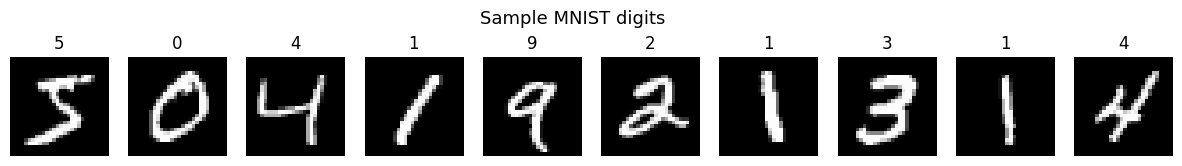

In [ ]:
# ── Cell 3: Load & Preprocess MNIST ───────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = np.expand_dims(x_train.astype('float32') / 255.0, -1)
x_test  = np.expand_dims(x_test.astype('float32')  / 255.0, -1)

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")

# Preview some samples
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i].squeeze(), cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=12)
    ax.axis('off')
plt.suptitle('Sample MNIST digits', fontsize=13)
plt.show()

In [ ]:
# ── Cell 4: Data Augmentation ──────────────────────────────────
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
)
datagen.fit(x_train)
print("Data augmentation ready ✅")

Data augmentation ready ✅


In [ ]:
# ── Cell 5: Build Model ────────────────────────────────────────
def build_model():
    inp = tf.keras.Input(shape=(28, 28, 1))

    # Block 1 — 32 filters
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2 — 64 filters
    x = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Classifier head
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    out = tf.keras.layers.Dense(10, activation='softmax')(x)

    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 870,634 (3.32 MB)

 Trainable params: 870,634 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Cell 6: Train ──────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
]

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=10,
    steps_per_epoch=len(x_train) // 128,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1,
)

_, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n🎯 Final Test Accuracy: {acc:.4%}")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


468/468 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.7512 - loss: 0.7369 - val_accuracy: 0.9866 - val_loss: 0.0365 - learning_rate: 0.0010
Epoch 2/10
  1/468 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9766 - loss: 0.1596

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9766 - loss: 0.1596 - val_accuracy: 0.9865 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 3/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9584 - loss: 0.1378 - val_accuracy: 0.9918 - val_loss: 0.0238 - learning_rate: 0.0010
Epoch 4/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9688 - loss: 0.0834 - val_accuracy: 0.9924 - val_loss: 0.0232 - learning_rate: 0.0010
Epoch 5/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9712 - loss: 0.0941 - val_accuracy: 0.9931 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 6/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 0.0202 - val_accuracy: 0.9932 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 7/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9772 - loss: 0.0735 - val_accuracy: 0.9930 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 8/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9922 - loss: 0.0255 - val_a

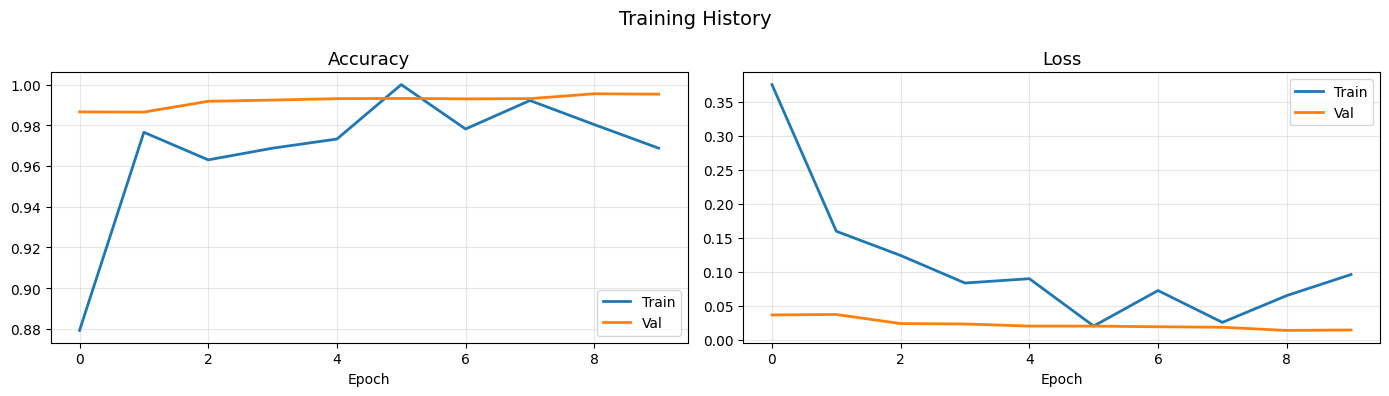

In [ ]:
# ── Cell 7: Plot Training History ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
ax1.set_title('Accuracy', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val',   linewidth=2)
ax2.set_title('Loss', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 8: Save & Download ────────────────────────────────────
MODEL_PATH = 'mnist_cnn_v2.keras'
model.save(MODEL_PATH)
print(f"✅ Model saved as '{MODEL_PATH}'")

# Auto-download to your laptop
from google.colab import files
files.download(MODEL_PATH)
print("📥 Download started — place the file next to neural_digit_recognition.py")

✅ Model saved as 'mnist_cnn_v2.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started — place the file next to neural_digit_recognition.py
